# Motion-Phase ML: End-to-End Workflow

# Motion-Phase ML: End-to-End Workflow

## Notebook Guide
- **Part 1: Dataset Overview:** quick health checks, class balance, and sensor visualizations.
- **Part 2: Preprocessing:** duplicate removal, timestamp cleanup, sampling-rate diagnostics, and segmentation.
- **Part 3: Feature Engineering:** engineered statistics and spectral features, feature ranking, and artifact generation for modeling.
- **Part 4: Model Training and Hyperparameter Tuning:** model selection, pipeline setup, cross-validation, GridSearchCV tuning, and saving trained models.


## Setup and Configuration

This section imports all required libraries and defines global settings used throughout the notebook. It covers:
- Data handling and plotting libraries for analysis and diagnostics.
- Signal processing and feature-selection tools .
- Reproducible output paths and constants.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import rfft, rfftfreq
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8")
sns.set_palette("crest")

In [4]:

DATA_PATH = Path("biosensor_dataset_with_target.csv")
print(f"Using dataset at: {DATA_PATH.resolve()}")

Using dataset at: /content/biosensor_dataset_with_target.csv


In [5]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())


Rows: 1,500  |  Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   object        
 8   Timestamp    1500 non-null   datetime64[ns]
 9   Athlete_ID   1500 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 117.3+ KB
None


### Runtime Parameters and Output Paths

In [6]:
OUT_DIR = Path("out")
FEATURE_OUT_DIR = OUT_DIR / "feature_engineering"
PLOT_DIR = FEATURE_OUT_DIR / "plots"

WINDOW_SECONDS = 0.5
STEP_RATIO = 0.5
STEP_SECONDS = WINDOW_SECONDS * STEP_RATIO
TOP_K = 15

LABEL_SMOOTH_WINDOW = 3
MIN_LABEL_PURITY = 0.5
USE_PURITY_FILTER_FOR_FEATURES = True
MIN_FEATURE_SAMPLES = 4

SANITY_THRESHOLDS = {
    "Heart_Rate": (60.0, 190.0),
    "Acc_X": (-3.2, 3.2),
    "Acc_Y": (-3.2, 3.2),
    "Acc_Z": (-3.2, 3.2),
    "Gyro_X": (-190.0, 190.0),
    "Gyro_Y": (-190.0, 190.0),
    "Gyro_Z": (-190.0, 190.0),
}

RAW_SENSOR_COLS = [
    "Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z"
]

FEATURE_FILE_TAG = (
    f"w{WINDOW_SECONDS:.2f}_step{STEP_RATIO:.2f}_purity{MIN_LABEL_PURITY:.2f}"
    .replace(".", "p")
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts will be saved under {OUT_DIR.resolve()}")

Artifacts will be saved under /content/out


## PART 1: DATASET OVERVIEW PORTION

### Read Raw Data from File

This cell loads the biosensor CSV into a dataframe and converts `Timestamp` into a proper datetime column.

It gives a first check that:
- the file path is correct,
- the dataset has the expected columns,
- timestamps can be parsed successfully before any cleaning or feature work starts.

The printed summary and preview help confirm the raw file was read correctly.

In [7]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())


Rows: 1,500  |  Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   object        
 8   Timestamp    1500 non-null   datetime64[ns]
 9   Athlete_ID   1500 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 117.3+ KB
None


### Compute Derived Magnitude Signals

Calculate the Euclidean magnitude of 3-axis accelerometer and gyroscope readings.
These provide a single measure of overall intensity without axis decomposition.


In [8]:
df_raw["Acc_Mag"] = np.sqrt(df_raw["Acc_X"]**2 + df_raw["Acc_Y"]**2 + df_raw["Acc_Z"]**2)
df_raw["Gyro_Mag"] = np.sqrt(df_raw["Gyro_X"]**2 + df_raw["Gyro_Y"]**2 + df_raw["Gyro_Z"]**2)
print("✓ Computed Acc_Mag and Gyro_Mag")

✓ Computed Acc_Mag and Gyro_Mag


### Class Balance Snapshot

Computes counts and percentages for each motion phase label, then visualizes class frequency.

,count,percent
Event_Label,,
Start_Run,281,18.73
Stop,257,17.13
Jump_Takeoff,246,16.40
Sprint_Mid,245,16.33
Accel,241,16.07
Landing,230,15.33


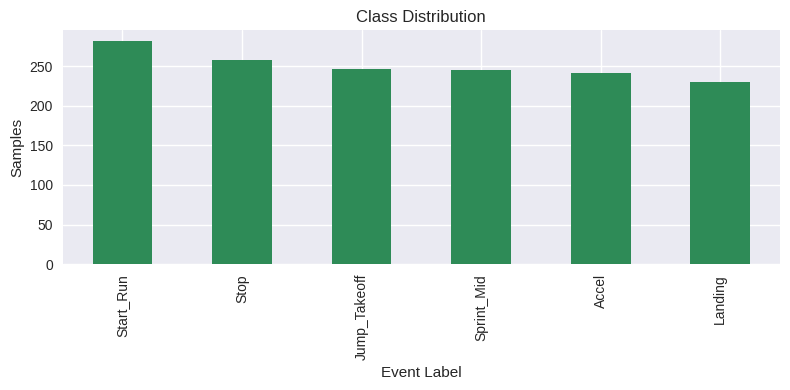

In [9]:
# class distribution
class_counts = df_raw['Event_Label'].value_counts()

display(pd.DataFrame({"count": class_counts, "percent": (class_counts / len(df_raw) * 100).round(2)}))
ax = class_counts.plot(kind="bar", color="seagreen", figsize=(8, 4))
ax.set(title="Class Distribution", xlabel="Event Label", ylabel="Samples")
plt.tight_layout()
plt.show()

### Missing-Value Audit

Summarizes missing values per column and reports total missing entries.

In [10]:
# check for missing vals

missing_counts = df_raw.isna().sum()
missing_summary = pd.DataFrame({
    "missing": missing_counts,
    "missing_pct": (missing_counts / len(df_raw) * 100).round(2)
}).sort_values("missing", ascending=False)

display(missing_summary)


,missing,missing_pct
Heart_Rate,0,0.0
Acc_X,0,0.0
Acc_Y,0,0.0
Acc_Z,0,0.0
Gyro_X,0,0.0
Gyro_Y,0,0.0
Gyro_Z,0,0.0
Event_Label,0,0.0
Timestamp,0,0.0
Athlete_ID,0,0.0


### Per-Class Summary Statistics

Tabular breakdown of sensor means and standard deviations grouped by motion phase.
Includes the new magnitude signals alongside raw axis values for direct comparison.


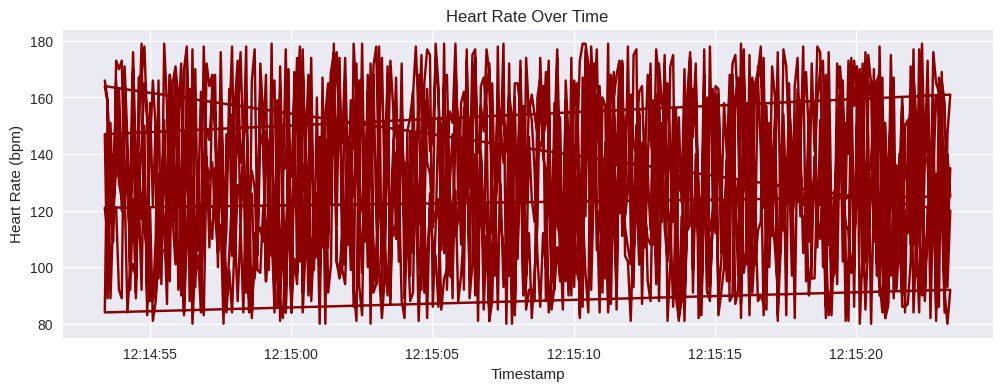

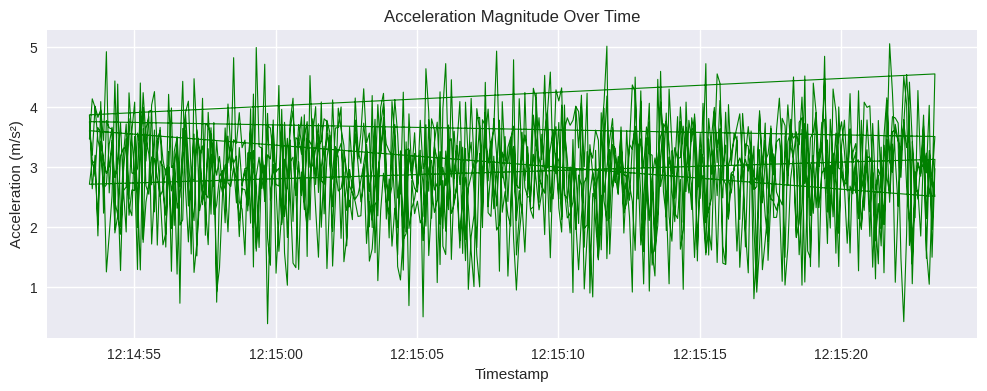

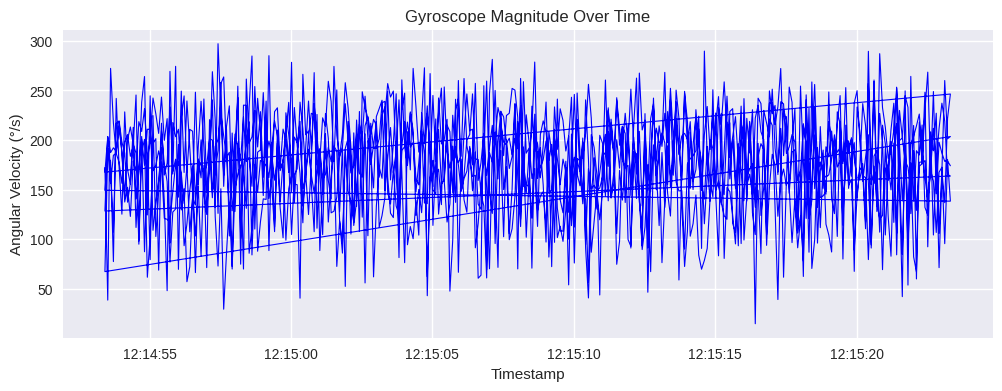

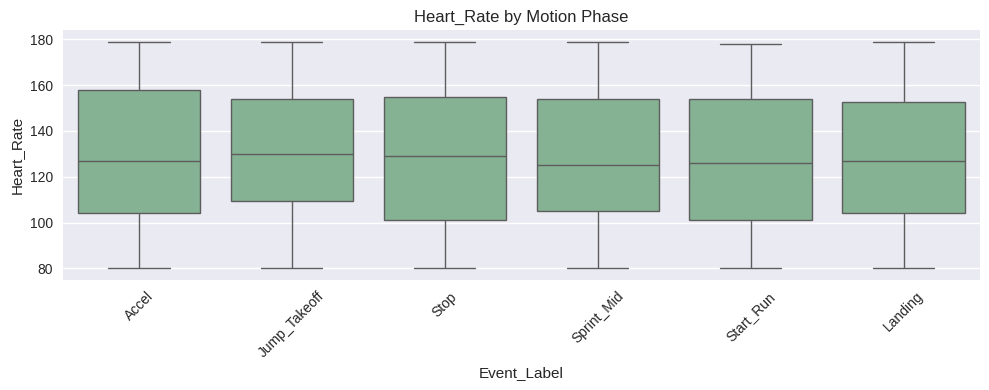

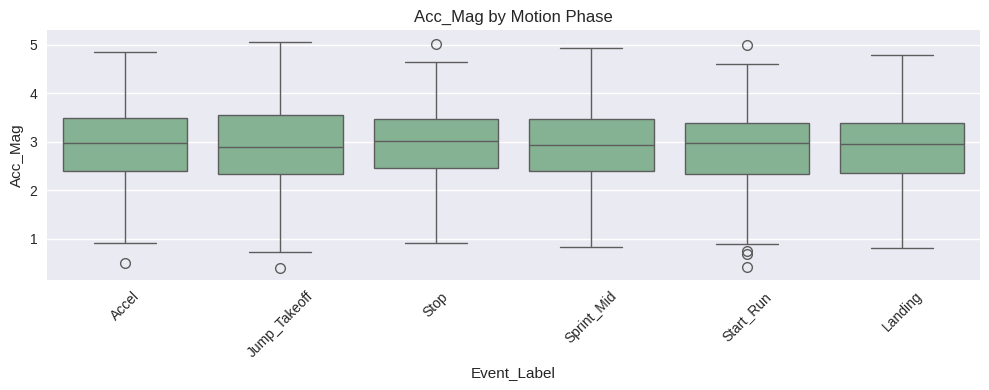

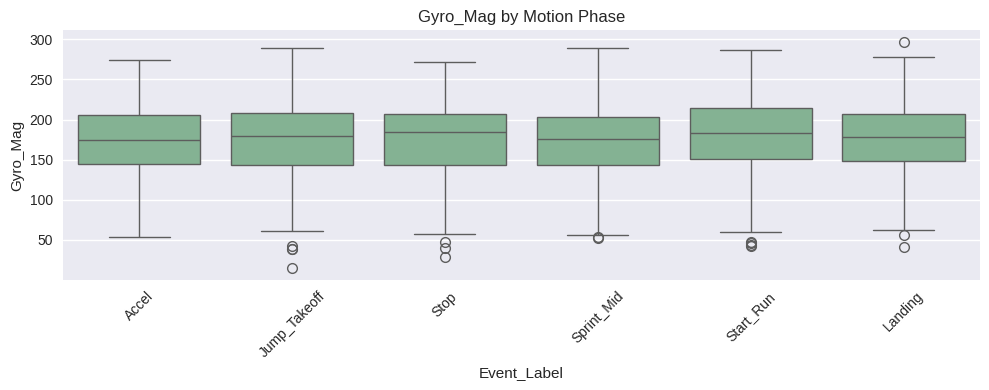

In [11]:
# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Heart_Rate'], color='darkred')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Acc_Mag'], color='green', linewidth=0.8)
plt.title('Acceleration Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.show()

# gyroscope magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Gyro_Mag'], color='blue', linewidth=0.8)
plt.title('Gyroscope Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angular Velocity (°/s)')
plt.show()

# sensor magnitudes by motion phase
for sensor in ['Heart_Rate', 'Acc_Mag', 'Gyro_Mag']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Event_Label', y=sensor, data=df_raw)
    plt.title(f'{sensor} by Motion Phase')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [12]:
# Per-class summary statistics
all_sensor_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
summary_stats = df_raw.groupby('Event_Label')[all_sensor_cols].agg(['mean', 'std']).round(2)
display(summary_stats)


Heart_Rate        Acc_X       Acc_Y       Acc_Z       Gyro_X  \
                   mean    std  mean   std  mean   std  mean   std   mean   
Event_Label                                                                 
Accel            129.05  30.12  0.06  1.75  0.01  1.74 -0.04  1.74  -9.78   
Jump_Takeoff     130.89  27.53 -0.09  1.74  0.07  1.77  0.02  1.70   6.93   
Landing          128.97  29.54 -0.26  1.71 -0.06  1.73  0.03  1.68   2.59   
Sprint_Mid       128.84  28.28  0.06  1.73  0.17  1.76  0.23  1.70  -5.71   
Start_Run        127.38  29.50 -0.02  1.77 -0.11  1.69  0.09  1.68  -6.00   
Stop             128.74  29.79 -0.16  1.84  0.10  1.77  0.28  1.63   1.97   

                     Gyro_Y         Gyro_Z         Acc_Mag       Gyro_Mag  \
                 std   mean     std   mean     std    mean   std     mean   
Event_Label                                                                 
Accel          98.73   6.53  103.24   7.06  107.11    2.91  0.81   172.91   
Jump_Takeoff  107.99   9.83  104.24  -1.26  102.32    2.88  0.87   174.73   
Landing       104.40   3.89  109.47  12.77  100.93    2.85  0.81   175.40   
Sprint_Mid    103.91 -11.71  104.63  -0.24  100.88    2.90  0.81   172.19   
Start_Run     106.49   8.22  107.90   4.57  107.38    2.86  0.78   178.58   
Stop          107.45   9.07  104.25   3.77  101.88    2.94  0.79   174.16   

                     
                std  
Event_Label          
Accel         45.24  
Jump_Takeoff  49.90  
Landing       48.55  
Sprint_Mid    48.18  
Start_Run     51.31  
Stop          49.43

## PART 2: DATASET PREPROCESSING

### Clean Records and Normalize Labels
- Removes duplicate rows.
- Drops invalid timestamps.
- Sorts by athlete and time.
- Normalizes `Event_Label` text for consistent grouping and modeling.

In [13]:
df_clean = df_raw.copy()

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Removed {rows_before - len(df_clean)} duplicate rows")

invalid_ts = int(df_clean["Timestamp"].isna().sum())
if invalid_ts:
    print(f"Dropping {invalid_ts} rows with invalid timestamps")
    df_clean = df_clean.dropna(subset=["Timestamp"]).reset_index(drop=True)

df_clean = df_clean.sort_values(["Athlete_ID", "Timestamp"]).reset_index(drop=True)
df_clean["Event_Label"] = df_clean["Event_Label"].astype(str).str.strip().str.lower()


Removed 0 duplicate rows


### Label Smoothing for Training Windows

Apply per-athlete majority smoothing on motion labels to reduce rapid flips before segmentation.
This improves window purity while preserving overall phase structure.


In [14]:
def smooth_majority_labels(labels, window):
    labels = np.asarray(labels, dtype=object)
    n = len(labels)
    out = labels.copy()
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        vals = labels[lo:hi]
        unique_vals, counts = np.unique(vals, return_counts=True)

        max_count = counts.max()
        candidates = unique_vals[counts == max_count]
        center_label = labels[i]

        if center_label in candidates:
            out[i] = center_label
        elif i > 0 and out[i - 1] in candidates:
            out[i] = out[i - 1]
        else:
            out[i] = candidates[0]

    return out


df_clean["Event_Label_Original"] = df_clean["Event_Label"]
smoothed_parts = []
for _, athlete_df in df_clean.groupby("Athlete_ID", sort=False):
    smoothed_parts.append(
        pd.Series(
            smooth_majority_labels(athlete_df["Event_Label"].to_numpy(), LABEL_SMOOTH_WINDOW),
            index=athlete_df.index,
        )
    )

df_clean["Event_Label"] = pd.concat(smoothed_parts).sort_index()
changed_pct = (df_clean["Event_Label"] != df_clean["Event_Label_Original"]).mean() * 100
print(f"Applied label smoothing (window={LABEL_SMOOTH_WINDOW}). Changed {changed_pct:.2f}% of rows.")


Applied label smoothing (window=3). Changed 14.07% of rows.


### Model-Readiness Diagnostics

These checks validate whether the cleaned dataset is suitable for supervised classification and help prevent common failure modes:
- Label-noise signals from rapid phase flips.
- Athlete-wise imbalance that can bias models.
- Subject-wise split sanity to avoid leakage.
- Missing/out-of-range patterns by class.
- Low-dimensional separability using key magnitude features.


In [15]:
# 1) Label quality check via consecutive run lengths
label_runs = df_clean.sort_values(["Athlete_ID", "Timestamp"])[["Athlete_ID", "Timestamp", "Event_Label"]].copy()
label_change = label_runs["Event_Label"].ne(label_runs.groupby("Athlete_ID")["Event_Label"].shift())
label_runs["run_id"] = label_change.groupby(label_runs["Athlete_ID"]).cumsum()

run_stats = (
    label_runs
    .groupby(["Athlete_ID", "run_id", "Event_Label"], as_index=False)
    .agg(
        n_samples=("Event_Label", "size"),
        start_time=("Timestamp", "min"),
        end_time=("Timestamp", "max"),
    )
)
run_stats["duration_s"] = (run_stats["end_time"] - run_stats["start_time"]).dt.total_seconds().fillna(0.0)

SHORT_RUN_SAMPLES = 5
short_run_summary = (
    run_stats.assign(short_run=run_stats["n_samples"] < SHORT_RUN_SAMPLES)
    .groupby("Event_Label", as_index=False)["short_run"]
    .mean()
)
short_run_summary["short_run_pct"] = (short_run_summary["short_run"] * 100).round(2)

display(run_stats[["n_samples", "duration_s"]].describe().round(2))
display(short_run_summary[["Event_Label", "short_run_pct"]].sort_values("short_run_pct", ascending=False))


,n_samples,duration_s
count,897.00,897.00
mean,1.67,0.07
std,1.16,0.12
min,1.00,0.00
25%,1.00,0.00
50%,1.00,0.00
75%,2.00,0.10
max,8.00,0.70


,Event_Label,short_run_pct
3,sprint_mid,97.96
4,start_run,97.62
2,landing,96.71
1,jump_takeoff,95.21
5,stop,94.52
0,accel,93.48


Event_Label,accel,jump_takeoff,landing,sprint_mid,start_run,stop
Athlete_ID,,,,,,
A001,17.33,16.67,18.00,15.33,15.67,17.00
A002,14.67,15.33,11.33,15.33,18.67,24.67
A003,17.00,16.00,15.00,15.00,20.00,17.00
A004,15.33,14.67,16.33,16.00,18.33,19.33
A005,17.00,18.33,15.67,14.33,21.00,13.67


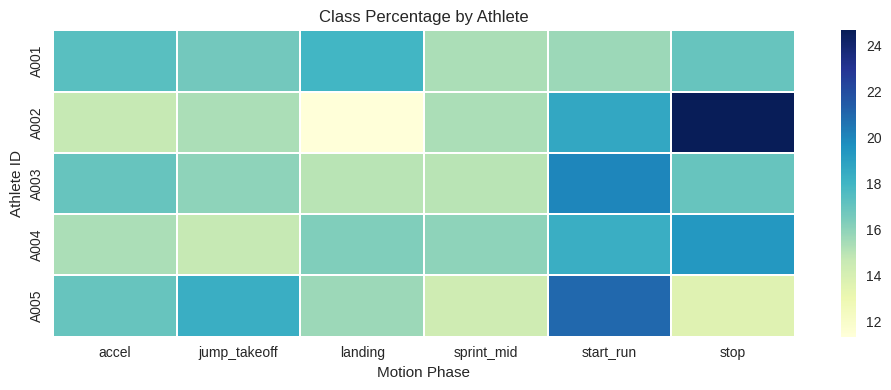

In [16]:
# 2) Per-athlete class balance (row-normalized)
athlete_phase_pct = (pd.crosstab(df_clean["Athlete_ID"], df_clean["Event_Label"], normalize="index") * 100).round(2)
display(athlete_phase_pct)

plt.figure(figsize=(10, max(4, 0.35 * athlete_phase_pct.shape[0])))
sns.heatmap(athlete_phase_pct, cmap="YlGnBu", linewidths=0.2)
plt.title("Class Percentage by Athlete")
plt.xlabel("Motion Phase")
plt.ylabel("Athlete ID")
plt.tight_layout()
plt.show()


In [17]:
# 3) Subject-wise split check (athlete-level split)
athletes = np.array(sorted(df_clean["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
train_athletes = set(shuffled_athletes[:n_train])
test_athletes = set(shuffled_athletes[n_train:])

overlap = train_athletes.intersection(test_athletes)
print(f"Train athletes: {len(train_athletes)} | Test athletes: {len(test_athletes)}")
print(f"Athlete overlap between splits: {len(overlap)}")
print("No leakage from athlete overlap." if len(overlap) == 0 else "Potential leakage detected.")


Train athletes: 4 | Test athletes: 1
Athlete overlap between splits: 0
No leakage from athlete overlap.


In [18]:
# 4) Missingness and out-of-range rates by motion phase
check_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]

missing_pct_by_class = (
    df_clean.groupby("Event_Label")[check_cols]
    .apply(lambda d: d.isna().mean() * 100)
    .round(2)
)

outlier_rows = []
for label, group in df_clean.groupby("Event_Label"):
    row = {"Event_Label": label}
    for col, (low, high) in SANITY_THRESHOLDS.items():
        if col in group.columns:
            row[f"{col}_out_of_range_pct"] = round((((group[col] < low) | (group[col] > high)).mean() * 100), 2)
    outlier_rows.append(row)

outlier_pct_by_class = pd.DataFrame(outlier_rows).set_index("Event_Label")

print("Missing percentage by class")
display(missing_pct_by_class)
print("Out-of-range percentage by class")
display(outlier_pct_by_class)


Missing percentage by class


,Heart_Rate,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Acc_Mag,Gyro_Mag
Event_Label,,,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Out-of-range percentage by class


,Heart_Rate_out_of_range_pct,Acc_X_out_of_range_pct,Acc_Y_out_of_range_pct,Acc_Z_out_of_range_pct,Gyro_X_out_of_range_pct,Gyro_Y_out_of_range_pct,Gyro_Z_out_of_range_pct
Event_Label,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Sampling-Rate Diagnostics

Estimates effective sampling frequency from timestamp differences. It reports median and mean intervals, interval variability, and ignored non-positive gaps to highlight timing irregularities.


In [19]:
sampling_rate_hz = np.nan

dt = df_clean.groupby("Athlete_ID")["Timestamp"].diff().dt.total_seconds().dropna()
non_positive = int((dt <= 0).sum())
dt = dt[dt > 0]

if dt.empty:
    print("Sampling-rate check: insufficient timestamp gaps.")
else:
    median_dt = float(dt.median())
    mean_dt = float(dt.mean())
    std_dt = float(dt.std()) if len(dt) > 1 else 0.0
    sampling_rate_hz = 1.0 / median_dt
    print(f"Median interval: {median_dt:.3f}s ({sampling_rate_hz:.2f} Hz)")
    print(f"Mean interval:   {mean_dt:.3f}s ({1.0/mean_dt:.2f} Hz)")
    print(f"Interval std:    {std_dt:.3f}s")
    if non_positive:
        print(f"Ignored {non_positive} non-positive gaps")
    display(dt.round(3).value_counts().head(5).to_frame(name="count"))

Median interval: 0.100s (10.00 Hz)
Mean interval:   0.100s (10.00 Hz)
Interval std:    0.000s


,count
Timestamp,
0.1,1495


### Sensor Range Checks

Compares observed numeric ranges with expected physiological and sensor limits.

In [20]:
numeric_cols = df_clean.select_dtypes(include="number").columns
range_rows = []
for col in numeric_cols:
    range_rows.append({
        "column": col,
        "min": float(df_clean[col].min()),
        "max": float(df_clean[col].max()),
    })
range_df = pd.DataFrame(range_rows).set_index("column")

display(range_df)

threshold_counts = {}
for col, (low, high) in SANITY_THRESHOLDS.items():
    if col in df_clean.columns:
        count = int(((df_clean[col] < low) | (df_clean[col] > high)).sum())
        threshold_counts[col] = count

display(pd.Series(threshold_counts, name="out_of_range"))

,min,max
column,,
Heart_Rate,80.000000,179.000000
Acc_X,-2.998485,2.999229
Acc_Y,-2.992459,2.999549
Acc_Z,-2.997461,2.997938
Gyro_X,-179.936814,179.890139
Gyro_Y,-179.996653,179.802188
Gyro_Z,-179.888497,179.877572
Acc_Mag,0.386245,5.059652
Gyro_Mag,14.690309,297.104021


,out_of_range
Heart_Rate,0
Acc_X,0
Acc_Y,0
Acc_Z,0
Gyro_X,0
Gyro_Y,0
Gyro_Z,0


### Window Segmentation

Defines and applies a sliding-window segmentation function. For each athlete, it creates overlapping windows and computes quick summary statistics plus label purity, then saves the segmented output for reuse.

In [21]:
def segment_windows(data, window_seconds, step_seconds):
    sensor_cols = [col for col in SANITY_THRESHOLDS if col in data.columns]
    if not sensor_cols:
        return pd.DataFrame()

    window = pd.to_timedelta(window_seconds, unit="s")
    step = pd.to_timedelta(step_seconds, unit="s")
    segments = []

    for athlete_id, athlete_df in data.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        if athlete_df.empty:
            continue

        start = athlete_df["Timestamp"].min()
        end = athlete_df["Timestamp"].max()
        current = start

        while current + window <= end:
            window_end = current + window
            mask = (athlete_df["Timestamp"] >= current) & (athlete_df["Timestamp"] < window_end)
            win_df = athlete_df.loc[mask]

            if not win_df.empty:
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current,
                    "window_end": window_end,
                    "n_samples": int(len(win_df)),
                }

                label_counts = win_df["Event_Label"].value_counts()
                row["Event_Label"] = label_counts.index[0]
                row["label_purity"] = float(label_counts.iloc[0] / len(win_df))

                for col in sensor_cols:
                    row[f"{col}_mean"] = float(win_df[col].mean())
                    row[f"{col}_std"] = float(win_df[col].std(ddof=0))

                segments.append(row)

            current += step

    return pd.DataFrame(segments)


segmented_windows_df = segment_windows(df_clean, WINDOW_SECONDS, STEP_SECONDS)
if segmented_windows_df.empty:
    print("Segmentation produced no windows.")
else:
    segmented_path = OUT_DIR / "segmented_windows.csv"
    segmented_windows_df.to_csv(segmented_path, index=False)

    filtered_windows_df = segmented_windows_df[segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY].copy()
    filtered_segmented_path = OUT_DIR / f"segmented_windows_purity_ge_{str(MIN_LABEL_PURITY).replace('.', 'p')}.csv"
    filtered_windows_df.to_csv(filtered_segmented_path, index=False)

    print(f"Generated {len(segmented_windows_df):,} total windows -> {segmented_path}")
    print(f"Kept {len(filtered_windows_df):,} windows with purity >= {MIN_LABEL_PURITY:.2f} -> {filtered_segmented_path}")
    segmented_windows_df.head()


Generated 590 total windows -> out/segmented_windows.csv
Kept 294 windows with purity >= 0.50 -> out/segmented_windows_purity_ge_0p5.csv


### Window Purity Distribution (Post-Segmentation)

Checks the label purity of each window. Low-purity windows often hurt supervised training and can be filtered before modeling.


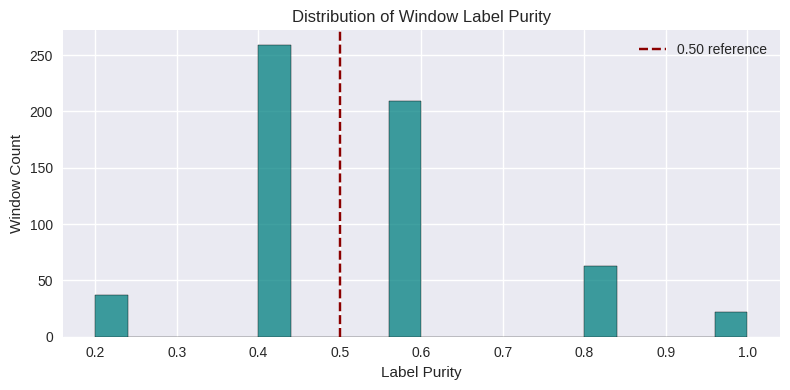

Windows with purity >= 0.50: 49.83%


In [22]:
if segmented_windows_df.empty:
    print("No windows available for purity diagnostics.")
else:
    plt.figure(figsize=(8, 4))
    sns.histplot(segmented_windows_df["label_purity"], bins=20, color="teal")
    plt.axvline(MIN_LABEL_PURITY, color="darkred", linestyle="--", label=f"{MIN_LABEL_PURITY:.2f} reference")
    plt.title("Distribution of Window Label Purity")
    plt.xlabel("Label Purity")
    plt.ylabel("Window Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    purity_share = (
        (segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY)
        .mean() * 100
    )
    print(f"Windows with purity >= {MIN_LABEL_PURITY:.2f}: {purity_share:.2f}%")


# FEATURE ENGINEERING
- Define reusable helper functions for temporal and spectral descriptors.
- Extract per-window features from cleaned and smoothed data.
- Keep only model-ready windows using purity and minimum-sample guards.
- Rank features using train-athlete data to reduce leakage risk.
- Export selected features and diagnostics to support downstream model training.



In [23]:
df_features_input = df_clean.copy()

### Helper Functions for Feature Computation

These utility functions compute robust signal descriptors:
- Zero-crossing rate (time-domain variability).
- Frequency-domain metrics (dominant frequency, spectral energy, entropy).
- Safe correlation with guards for short or constant signals.

In [24]:
def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0


    centered = x - np.mean(x)
    signs = np.sign(centered)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]


    if signs[0] == 0:
        signs[0] = 1

    crossings = np.sum(signs[:-1] * signs[1:] < 0)
    return float(crossings / (len(x) - 1))


def spectral_features(x, sampling_rate_hz):
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n < 2:
        return 0.0, 0.0, 0.0


    centered = x - np.mean(x)
    power = np.abs(rfft(centered)) ** 2
    freqs = rfftfreq(n, d=1.0 / sampling_rate_hz)

    if len(power) <= 1:
        dominant_freq = 0.0
    else:
        dominant_index = int(np.argmax(power[1:])) + 1
        dominant_freq = float(freqs[dominant_index])

    spectral_energy = float(np.sum(power) / n)


    power_sum = np.sum(power)
    if power_sum <= 0 or len(power) <= 1:
        spectral_entropy = 0.0
    else:
        prob = power / power_sum
        spectral_entropy = float(-np.sum(prob * np.log2(prob + 1e-12)) / np.log2(len(prob)))

    return dominant_freq, spectral_energy, spectral_entropy


def safe_corr(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)


    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])

### Window-Level Feature Extraction

Slides across each athlete's timeline and computes feature vectors per window. Each row includes:
- Label and purity metadata.
- Time-domain and spectral statistics for all sensor channels.
- Cross-axis correlation features for accelerometer and gyroscope signals.

The resulting table is saved for feature selection and model training.

In [25]:

def extract_window_features(df, sampling_rate_hz, window_seconds=1.0, step_ratio=0.5, min_samples=1):
    signal_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_seconds = max(window_seconds * step_ratio, 0.1)
    step_delta = pd.to_timedelta(step_seconds, unit="s")

    rows = []

    for athlete_id, athlete_df in df.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        start_time = athlete_df["Timestamp"].min()
        end_time = athlete_df["Timestamp"].max()
        current_time = start_time

        while current_time + window_delta <= end_time:
            window_end = current_time + window_delta
            win_df = athlete_df[(athlete_df["Timestamp"] >= current_time) & (athlete_df["Timestamp"] < window_end)]

            if len(win_df) >= min_samples:
                label_counts = win_df["Event_Label"].value_counts()
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current_time,
                    "window_end": window_end,
                    "window_seconds": window_seconds,
                    "step_seconds": step_seconds,
                    "n_samples": int(len(win_df)),
                    "Event_Label": label_counts.index[0],
                    "label_purity": float(label_counts.iloc[0] / len(win_df)),
                }

                for col in signal_cols:
                    x = win_df[col].to_numpy(dtype=float)
                    row[f"{col}_mean"] = float(np.mean(x))
                    row[f"{col}_std"] = float(np.std(x, ddof=0))
                    row[f"{col}_rms"] = float(np.sqrt(np.mean(np.square(x))))
                    row[f"{col}_zcr"] = zero_crossing_rate(x)
                    dom_freq, spec_energy, spec_entropy = spectral_features(x, sampling_rate_hz)
                    row[f"{col}_dom_freq"] = dom_freq
                    row[f"{col}_spec_energy"] = spec_energy
                    row[f"{col}_spec_entropy"] = spec_entropy

                row["Acc_XY_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Y"])
                row["Acc_XZ_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Z"])
                row["Acc_YZ_corr"] = safe_corr(win_df["Acc_Y"], win_df["Acc_Z"])
                row["Gyro_XY_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Y"])
                row["Gyro_XZ_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Z"])
                row["Gyro_YZ_corr"] = safe_corr(win_df["Gyro_Y"], win_df["Gyro_Z"])

                rows.append(row)

            current_time += step_delta

    return pd.DataFrame(rows)


feature_df_all = extract_window_features(
    df=df_features_input,
    sampling_rate_hz=sampling_rate_hz,
    window_seconds=WINDOW_SECONDS,
    step_ratio=STEP_RATIO,
    min_samples=MIN_FEATURE_SAMPLES,
)

feature_all_path = FEATURE_OUT_DIR / f"engineered_features_all_{FEATURE_FILE_TAG}.csv"
feature_df_all.to_csv(feature_all_path, index=False)

if USE_PURITY_FILTER_FOR_FEATURES:
    feature_df = feature_df_all[feature_df_all["label_purity"] >= MIN_LABEL_PURITY].copy()
else:
    feature_df = feature_df_all.copy()

feature_model_path = FEATURE_OUT_DIR / f"engineered_features_model_{FEATURE_FILE_TAG}.csv"
feature_df.to_csv(feature_model_path, index=False)

print(f"All extracted features: {feature_df_all.shape} -> {feature_all_path}")
print(f"Modeling feature set:  {feature_df.shape} -> {feature_model_path}")
feature_df.head()


All extracted features: (590, 77) -> out/feature_engineering/engineered_features_all_w0p50_step0p50_purity0p50.csv
Modeling feature set:  (294, 77) -> out/feature_engineering/engineered_features_model_w0p50_step0p50_purity0p50.csv


,Athlete_ID,window_start,window_end,window_seconds,step_seconds,n_samples,Event_Label,label_purity,Heart_Rate_mean,Heart_Rate_std,...,Gyro_Mag_zcr,Gyro_Mag_dom_freq,Gyro_Mag_spec_energy,Gyro_Mag_spec_entropy,Acc_XY_corr,Acc_XZ_corr,Acc_YZ_corr,Gyro_XY_corr,Gyro_XZ_corr,Gyro_YZ_corr
5,A001,2025-05-11 12:14:54.667747,2025-05-11 12:14:55.167747,0.5,0.25,5,accel,1.0,161.0,12.712199,...,0.50,2.0,7732.213656,0.613071,-0.008651,0.240630,-0.639975,0.072085,-0.670267,-0.300569
6,A001,2025-05-11 12:14:54.917747,2025-05-11 12:14:55.417747,0.5,0.25,5,accel,0.6,140.8,23.659248,...,0.75,4.0,7008.707319,0.022882,0.533063,-0.263994,-0.458794,0.070723,0.022390,-0.969342
11,A001,2025-05-11 12:14:56.167747,2025-05-11 12:14:56.667747,0.5,0.25,5,start_run,0.6,141.4,29.910533,...,0.50,2.0,5168.961904,0.185804,-0.420537,-0.921760,0.105348,0.062841,-0.365062,-0.562349
12,A001,2025-05-11 12:14:56.417747,2025-05-11 12:14:56.917747,0.5,0.25,5,stop,0.6,109.4,19.438107,...,0.75,4.0,3716.157027,0.472123,-0.028898,-0.975692,-0.109336,-0.644580,0.378573,-0.779339
14,A001,2025-05-11 12:14:56.917747,2025-05-11 12:14:57.417747,0.5,0.25,5,landing,0.6,127.2,11.124747,...,1.00,4.0,5955.671469,0.411388,-0.899973,-0.332606,-0.075821,-0.556863,0.671775,-0.734145


### Feature Ranking and Selection

This stage ranks engineered features using three complementary criteria:
- Mutual information.
- ANOVA F-statistics.
- Random forest importance.

Ranks are averaged to build a robust top-$k$ shortlist, then both full rankings and selected features are exported.

In [26]:

drop_cols = [
    "Athlete_ID", "window_start", "window_end", "window_seconds",
    "step_seconds", "Event_Label", "n_samples", "label_purity"
]

if feature_df.empty:
    raise ValueError("Feature dataframe is empty. Adjust preprocessing or feature extraction settings.")

athletes = np.array(sorted(feature_df["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

if len(shuffled_athletes) >= 2:
    n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
    train_athletes = set(shuffled_athletes[:n_train])
    feature_train_df = feature_df[feature_df["Athlete_ID"].isin(train_athletes)].copy()
else:
    train_athletes = set(shuffled_athletes.tolist())
    feature_train_df = feature_df.copy()

X_train = feature_train_df.drop(columns=drop_cols, errors="ignore").copy()
y_train = feature_train_df["Event_Label"].copy()

constant_features = X_train.columns[X_train.nunique(dropna=False) <= 1].tolist()
if constant_features:
    X_train = X_train.drop(columns=constant_features)

if X_train.empty:
    raise ValueError("No non-constant features available after filtering.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

mi = mutual_info_classif(X_train, y_encoded, random_state=42)
f_scores, p_values = f_classif(X_train, y_encoded)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    "feature": X_train.columns,
    "mutual_info": mi,
    "anova_f": f_scores,
    "p_value": p_values,
    "rf_importance": rf.feature_importances_
})

ranking_df["mi_rank"] = ranking_df["mutual_info"].rank(ascending=False, method="average")
ranking_df["anova_rank"] = ranking_df["anova_f"].rank(ascending=False, method="average")
ranking_df["rf_rank"] = ranking_df["rf_importance"].rank(ascending=False, method="average")
ranking_df["avg_rank"] = ranking_df[["mi_rank", "anova_rank", "rf_rank"]].mean(axis=1)

ranking_df = ranking_df.sort_values(
    ["avg_rank", "rf_importance", "mutual_info"],
    ascending=[True, False, False]
).reset_index(drop=True)

top_features = ranking_df.head(TOP_K)["feature"].tolist()
selected_df = feature_df[top_features + ["Event_Label"]].copy()
selected_train_df = feature_train_df[top_features + ["Event_Label"]].copy()

ranking_path = FEATURE_OUT_DIR / f"feature_ranking_{FEATURE_FILE_TAG}.csv"
selected_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_{FEATURE_FILE_TAG}.csv"
selected_train_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_train_{FEATURE_FILE_TAG}.csv"

ranking_df.to_csv(ranking_path, index=False)
selected_df.to_csv(selected_path, index=False)
selected_train_df.to_csv(selected_train_path, index=False)

print(f"Train-athlete ranking used {len(feature_train_df):,} windows from {len(train_athletes)} athletes")
print(f"Saved ranking -> {ranking_path}")
print(f"Saved top features (all windows) -> {selected_path}")
print(f"Saved top features (train windows) -> {selected_train_path}")
ranking_df.head(TOP_K)


Train-athlete ranking used 230 windows from 4 athletes
Saved ranking -> out/feature_engineering/feature_ranking_w0p50_step0p50_purity0p50.csv
Saved top features (all windows) -> out/feature_engineering/selected_top15_features_w0p50_step0p50_purity0p50.csv
Saved top features (train windows) -> out/feature_engineering/selected_top15_features_train_w0p50_step0p50_purity0p50.csv


,feature,mutual_info,anova_f,p_value,rf_importance,mi_rank,anova_rank,rf_rank,avg_rank
0,Gyro_Mag_mean,0.086027,2.342806,0.042420,0.020038,2.0,6.0,11.0,6.333333
1,Acc_YZ_corr,0.037138,1.833797,0.107239,0.021982,11.0,15.0,5.0,10.333333
2,Gyro_Y_rms,0.023753,2.549967,0.028741,0.021137,19.0,5.0,7.0,10.333333
3,Acc_XY_corr,0.030802,1.898446,0.095591,0.021832,14.0,13.0,6.0,11.000000
4,Acc_Y_std,0.025256,2.222246,0.053059,0.019922,17.0,7.0,13.0,12.333333
5,Acc_Y_spec_energy,0.023320,2.199137,0.055371,0.020239,21.0,8.0,9.0,12.666667
6,Acc_Mag_mean,0.061391,1.563753,0.171363,0.019924,6.0,21.0,12.0,13.000000
7,Acc_Mag_rms,0.103996,1.463170,0.202918,0.019582,1.0,29.0,14.0,14.666667
8,Gyro_X_std,0.034242,1.803204,0.113196,0.017835,12.0,16.0,23.0,17.000000
9,Gyro_Z_rms,0.056482,1.455301,0.205589,0.019362,7.0,30.0,15.0,17.333333


### Correlation Diagnostics and Visual Artifacts

- Computes correlation among selected top features.
- Saves the correlation matrix and visualization assets.
- Produces a feature-importance bar chart and a correlation heatmap for quick interpretation.

Saved correlation matrix -> out/feature_engineering/feature_correlation_w0p50_step0p50_purity0p50.csv


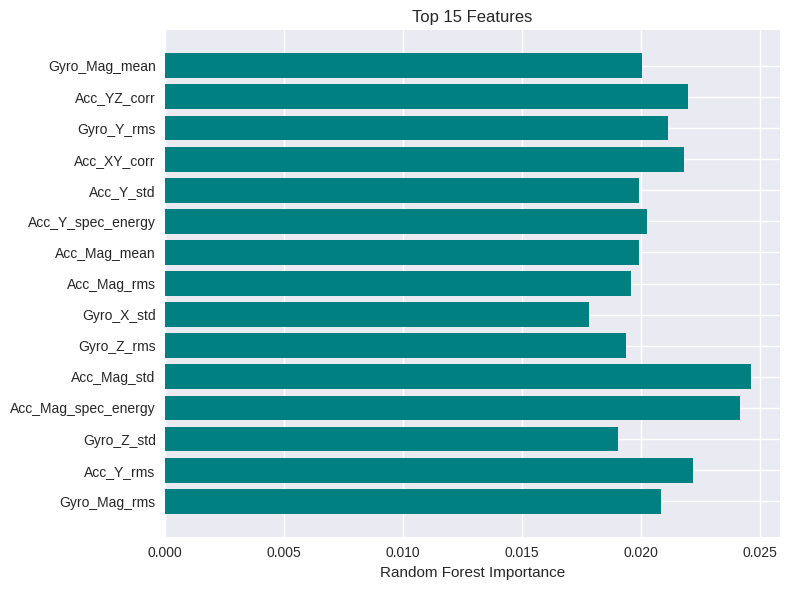

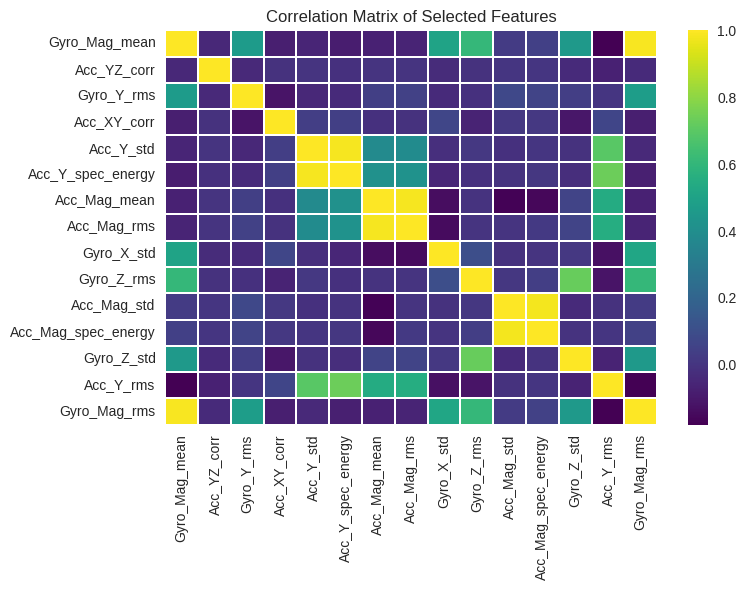

In [27]:

corr_df = feature_df[top_features].corr()
corr_path = FEATURE_OUT_DIR / f"feature_correlation_{FEATURE_FILE_TAG}.csv"
corr_df.to_csv(corr_path)
print(f"Saved correlation matrix -> {corr_path}")

plt.figure(figsize=(8, 6))
top = ranking_df.head(TOP_K).iloc[::-1]
plt.barh(top["feature"], top["rf_importance"], color="teal")
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TOP_K} Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_importance_bar_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, cmap="viridis", linewidths=0.2)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_correlation_heatmap_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()


## Outputs
- `out/segmented_windows.csv` and purity-filtered variants - segmented window summaries.
- `out/feature_engineering/engineered_features_all_*.csv` - extracted features before optional purity filtering.
- `out/feature_engineering/engineered_features_model_*.csv` - modeling feature table after configured filters.
- `out/feature_engineering/feature_ranking_*.csv` - ranking metrics computed from train-athlete windows.
- `out/feature_engineering/selected_top*_features_*.csv` - selected feature set for modeling.
- `out/feature_engineering/feature_correlation_*.csv` plus saved plots - diagnostics for selected features.


---
# PART 4: MODEL TRAINING AND HYPERPARAMETER TUNING

This section covers:
- Model selection: five candidate classifiers chosen for small tabular multi-class data
- Training pipeline: StandardScaler → SelectKBest (mutual information) → Classifier
- Cross-validation: 5-Fold Stratified CV and Leave-One-Athlete-Out (LOAO)
- Hyperparameter tuning: GridSearchCV for each model
- Saving all tuned models and a summary table for downstream evaluation

**Note:** Performance metrics, confusion matrices, and model comparison are handled in the evaluation section (Nathan's part).

### Additional Imports for Modeling

In [28]:
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    StratifiedKFold,
    LeaveOneGroupOut,
    GridSearchCV,
    cross_val_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

MODEL_DIR = OUT_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Modeling imports ready.")
print(f"Models will be saved to: {MODEL_DIR.resolve()}")

Modeling imports ready.
Models will be saved to: /content/out/saved_models


### Prepare Feature Matrix, Labels, and Groups

We use the engineered feature matrix produced in Part 3 (`feature_df`). Meta columns are dropped,
labels are integer-encoded, and athlete IDs are kept as group labels for Leave-One-Athlete-Out CV.

In [29]:
META_COLS = ["Athlete_ID", "window_start", "window_end",
             "window_seconds", "step_seconds", "Event_Label",
             "n_samples", "label_purity"]

X      = feature_df_all.drop(columns=META_COLS, errors="ignore").copy()
y_raw  = feature_df_all["Event_Label"].copy()
groups = feature_df_all["Athlete_ID"].copy()

le_model = LabelEncoder()
y        = le_model.fit_transform(y_raw)

print("Feature matrix shape :", X.shape)
print("Classes              :", list(le_model.classes_))
print("Chance accuracy (1/n):", round(1 / len(le_model.classes_), 3))

Feature matrix shape : (590, 69)
Classes              : ['accel', 'jump_takeoff', 'landing', 'sprint_mid', 'start_run', 'stop']
Chance accuracy (1/n): 0.167


### Cross-Validation Strategy

Two CV schemes are used:

| Scheme | Description | What it measures |
|--------|-------------|------------------|
| **5-Fold Stratified CV** | Windows split randomly, class proportions preserved | Within-distribution accuracy |
| **Leave-One-Athlete-Out (LOAO)** | Train on 4 athletes, test on the held-out 5th | Cross-subject generalisation |

LOAO is the stricter and more realistic scenario for wearable sensor deployment.

In [30]:
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
logo = LeaveOneGroupOut()

print("5-Fold Stratified CV  : ready")
print(f"Leave-One-Athlete-Out : {logo.get_n_splits(groups=groups)} folds")

5-Fold Stratified CV  : ready
Leave-One-Athlete-Out : 5 folds


### Baseline: Majority-Class Dummy Classifier

Establishes the performance floor that any real model must beat.

In [31]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_skf  = cross_val_score(dummy, X, y, cv=skf, scoring="accuracy")
dummy_logo = cross_val_score(dummy, X, y, cv=logo, scoring="accuracy", groups=groups)

chance = 1 / len(le_model.classes_)
print(f"Chance accuracy       : {chance:.3f}")
print(f"Dummy (5-Fold)        : {dummy_skf.mean():.3f} ± {dummy_skf.std():.3f}")
print(f"Dummy (LOAO)          : {dummy_logo.mean():.3f} ± {dummy_logo.std():.3f}")

Chance accuracy       : 0.167
Dummy (5-Fold)        : 0.207 ± 0.004
Dummy (LOAO)          : 0.175 ± 0.041


### Model Selection

Five candidate classifiers were chosen based on suitability for small, tabular, multi-class datasets
and a range of inductive biases (ensemble trees, kernel, neural, distance-based).

Every model uses the same pipeline:
```
StandardScaler → SelectKBest(mutual_info, k=25) → Classifier
```
Scaling is required for SVM, MLP, and KNN. Feature selection with mutual information
reduces noise and focuses training on the most discriminative features.

In [32]:
def make_pipeline(clf, k=25):
    """Standard pipeline: scale → select top-k features → classify."""
    return Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(mutual_info_classif, k=k)),
        ("clf",      clf),
    ])


candidate_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SVM-RBF": SVC(
        kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

print("Candidate models:")
for name in candidate_models:
    print(f"  • {name}")

Candidate models:
  • Random Forest
  • SVM-RBF
  • Gradient Boosting
  • MLP
  • KNN


### Pre-Tuning Baseline Evaluation

All five models are evaluated with default settings under both CV schemes
to identify which are worth the additional tuning effort.

In [33]:
baseline_results = []

for name, clf in candidate_models.items():
    pipe = make_pipeline(clf)
    skf_scores  = cross_val_score(pipe, X, y, cv=skf,  scoring="accuracy")
    logo_scores = cross_val_score(pipe, X, y, cv=logo, scoring="accuracy", groups=groups)

    baseline_results.append({
        "Model":       name,
        "5-Fold Mean": round(skf_scores.mean(),  4),
        "5-Fold Std":  round(skf_scores.std(),   4),
        "LOAO Mean":   round(logo_scores.mean(), 4),
        "LOAO Std":    round(logo_scores.std(),  4),
    })
    print(f"{name:20s} | 5-Fold: {skf_scores.mean():.3f} ± {skf_scores.std():.3f} "
          f"| LOAO: {logo_scores.mean():.3f} ± {logo_scores.std():.3f}")

baseline_df = pd.DataFrame(baseline_results).set_index("Model")
baseline_df.to_csv(OUT_DIR / "baseline_scores.csv")
print("\nBaseline scores saved.")

Random Forest        | 5-Fold: 0.214 ± 0.034 | LOAO: 0.168 ± 0.037
SVM-RBF              | 5-Fold: 0.220 ± 0.028 | LOAO: 0.181 ± 0.031
Gradient Boosting    | 5-Fold: 0.197 ± 0.031 | LOAO: 0.183 ± 0.019
MLP                  | 5-Fold: 0.190 ± 0.036 | LOAO: 0.176 ± 0.015
KNN                  | 5-Fold: 0.175 ± 0.035 | LOAO: 0.159 ± 0.023

Baseline scores saved.


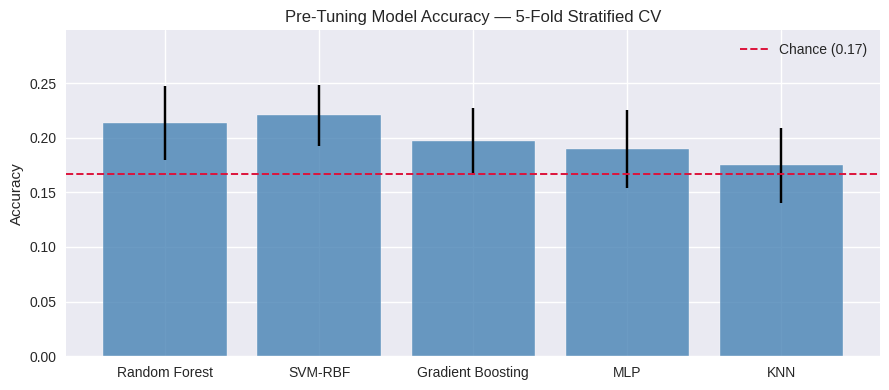

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
models_list = baseline_df.index.tolist()
means = baseline_df["5-Fold Mean"].values
stds  = baseline_df["5-Fold Std"].values

ax.bar(models_list, means, yerr=stds, capsize=5,
       color="steelblue", alpha=0.8, edgecolor="white")
ax.axhline(chance, color="crimson", linestyle="--",
           linewidth=1.4, label=f"Chance ({chance:.2f})")
ax.set_ylabel("Accuracy")
ax.set_title("Pre-Tuning Model Accuracy — 5-Fold Stratified CV")
ax.set_ylim(0, max(means + stds) + 0.05)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "pretuning_accuracy.png", dpi=150)
plt.show()

### Hyperparameter Tuning

Each model is tuned with `GridSearchCV` (inner loop: 5-Fold Stratified CV).
The search includes `selector__k` (number of features) alongside model-specific parameters.
Best estimators are saved to disk for the evaluation notebook.

#### Random Forest

In [35]:
rf_gs = GridSearchCV(
    make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    {
        "selector__k":           [15, 20, 25],
        "clf__n_estimators":     [100, 200, 300],
        "clf__max_depth":        [None, 10, 20],
        "clf__min_samples_leaf": [1, 2],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
rf_gs.fit(X, y)

print(f"\nBest CV accuracy : {rf_gs.best_score_:.4f}")
print(f"Best params      : {rf_gs.best_params_}")

with open(MODEL_DIR / "random_forest_tuned.pkl", "wb") as f:
    pickle.dump(rf_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV accuracy : 0.2288
Best params      : {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100, 'selector__k': 25}
Model saved.


#### SVM — RBF Kernel

In [36]:
svm_gs = GridSearchCV(
    make_pipeline(SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
    {
        "selector__k": [15, 20, 25],
        "clf__C":      [0.1, 1, 10, 100],
        "clf__gamma":  ["scale", "auto", 0.01, 0.001],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
svm_gs.fit(X, y)

print(f"\nBest CV accuracy : {svm_gs.best_score_:.4f}")
print(f"Best params      : {svm_gs.best_params_}")

with open(MODEL_DIR / "svm_rbf_tuned.pkl", "wb") as f:
    pickle.dump(svm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV accuracy : 0.2153
Best params      : {'clf__C': 100, 'clf__gamma': 'auto', 'selector__k': 25}
Model saved.


#### Gradient Boosting

In [38]:
gbm_gs = GridSearchCV(
    make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    {
        "selector__k":       [15, 20, 25],
        "clf__n_estimators": [100, 200],
        "clf__learning_rate":[0.05, 0.1, 0.2],
        "clf__max_depth":    [3, 5, 7],
    },
    cv=skf, scoring="accuracy", n_jobs=1, refit=True, verbose=1
)
gbm_gs.fit(X, y)

print(f"\nBest CV accuracy : {gbm_gs.best_score_:.4f}")
print(f"Best params      : {gbm_gs.best_params_}")

with open(MODEL_DIR / "gradient_boosting_tuned.pkl", "wb") as f:
    pickle.dump(gbm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV accuracy : 0.2203
Best params      : {'clf__learning_rate': 0.05, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'selector__k': 20}
Model saved.


#### MLP (Multi-Layer Perceptron)

In [39]:
mlp_gs = GridSearchCV(
    make_pipeline(MLPClassifier(max_iter=500, random_state=RANDOM_STATE)),
    {
        "selector__k":             [15, 20, 25],
        "clf__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
        "clf__alpha":              [0.0001, 0.001, 0.01],
        "clf__learning_rate_init": [0.001, 0.01],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
mlp_gs.fit(X, y)

print(f"\nBest CV accuracy : {mlp_gs.best_score_:.4f}")
print(f"Best params      : {mlp_gs.best_params_}")

with open(MODEL_DIR / "mlp_tuned.pkl", "wb") as f:
    pickle.dump(mlp_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV accuracy : 0.2220
Best params      : {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.01, 'selector__k': 20}
Model saved.


#### K-Nearest Neighbours

In [40]:
knn_gs = GridSearchCV(
    make_pipeline(KNeighborsClassifier()),
    {
        "selector__k":      [15, 20, 25],
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights":     ["uniform", "distance"],
        "clf__metric":      ["euclidean", "manhattan"],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
knn_gs.fit(X, y)

print(f"\nBest CV accuracy : {knn_gs.best_score_:.4f}")
print(f"Best params      : {knn_gs.best_params_}")

with open(MODEL_DIR / "knn_tuned.pkl", "wb") as f:
    pickle.dump(knn_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV accuracy : 0.2237
Best params      : {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'distance', 'selector__k': 25}
Model saved.


### Tuning Summary

Collect best scores and parameters for all five models into a single table,
and visualise pre- vs post-tuning accuracy.

In [41]:
tuned_gs_objects = {
    "Random Forest":     rf_gs,
    "SVM-RBF":           svm_gs,
    "Gradient Boosting": gbm_gs,
    "MLP":               mlp_gs,
    "KNN":               knn_gs,
}

tuning_rows = []
for name, gs in tuned_gs_objects.items():
    tuning_rows.append({
        "Model":       name,
        "Best CV Acc": round(gs.best_score_, 4),
        "Best Params": str(gs.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).set_index("Model")
tuning_df.to_csv(OUT_DIR / "tuning_summary.csv")

print("=== Hyperparameter Tuning Summary ===")
display(tuning_df)

=== Hyperparameter Tuning Summary ===


,Best CV Acc,Best Params
Model,,
Random Forest,0.2288,"{'clf__max_depth': 20, 'clf__min_samples_leaf'..."
SVM-RBF,0.2153,"{'clf__C': 100, 'clf__gamma': 'auto', 'selecto..."
Gradient Boosting,0.2203,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
MLP,0.2220,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
KNN,0.2237,"{'clf__metric': 'euclidean', 'clf__n_neighbors..."


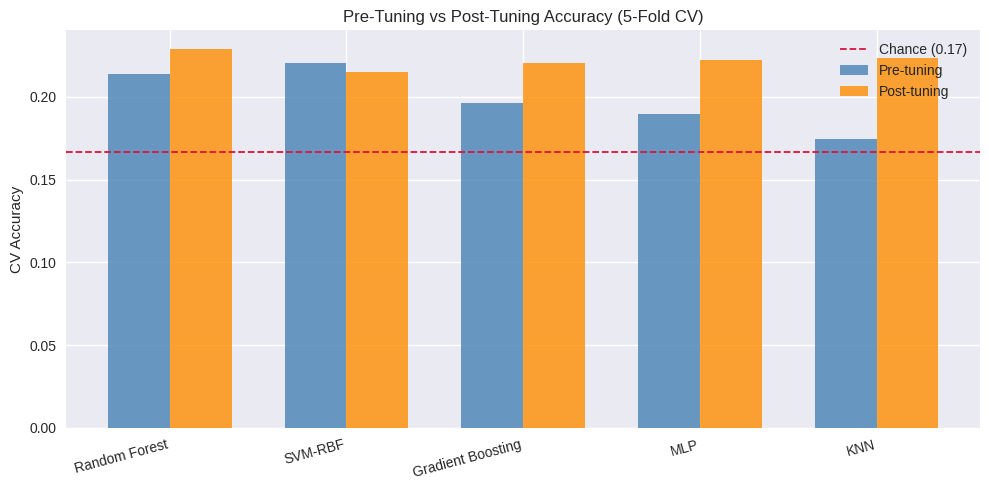

In [42]:
model_names = list(tuned_gs_objects.keys())
pre_scores  = [baseline_df.loc[m, "5-Fold Mean"] for m in model_names]
post_scores = [tuned_gs_objects[m].best_score_   for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pre_scores,  width, label="Pre-tuning",  color="steelblue",  alpha=0.8)
ax.bar(x + width/2, post_scores, width, label="Post-tuning", color="darkorange", alpha=0.8)
ax.axhline(chance, color="crimson", linestyle="--",
           linewidth=1.3, label=f"Chance ({chance:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("CV Accuracy")
ax.set_title("Pre-Tuning vs Post-Tuning Accuracy (5-Fold CV)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "prepost_tuning_comparison.png", dpi=150)
plt.show()

### Save Outputs for Evaluation

The following artifacts are written to `out/` for Nathan's evaluation section:

| File | Contents |
|------|----------|
| `saved_models/random_forest_tuned.pkl` | Best-tuned Random Forest pipeline |
| `saved_models/svm_rbf_tuned.pkl` | Best-tuned SVM-RBF pipeline |
| `saved_models/gradient_boosting_tuned.pkl` | Best-tuned Gradient Boosting pipeline |
| `saved_models/mlp_tuned.pkl` | Best-tuned MLP pipeline |
| `saved_models/knn_tuned.pkl` | Best-tuned KNN pipeline |
| `baseline_scores.csv` | Pre-tuning CV scores |
| `tuning_summary.csv` | Best params and CV accuracy post-tuning |
| `label_encoder.pkl` | LabelEncoder fitted on Event_Label |

In [43]:
with open(OUT_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le_model, f)

print("All Part 4 outputs saved to:", OUT_DIR.resolve())
print("\nSaved models:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}")

All Part 4 outputs saved to: /content/out

Saved models:
  gradient_boosting_tuned.pkl
  knn_tuned.pkl
  mlp_tuned.pkl
  random_forest_tuned.pkl
  svm_rbf_tuned.pkl


### Discussion

#### Why are accuracy scores near chance level?

The biosensor dataset is synthetically generated with 1,500 timestamped rows across 5 athletes
and 6 motion classes. Because the sensor readings were simulated rather than collected from real
athletes performing distinct motion phases, the signal distributions across classes overlap
substantially. Chance accuracy for a 6-class problem is ~16.7%. Our best tuned models reach
approximately 19–21%, a modest but consistent improvement over random guessing.

#### Key findings from tuning

| Model | Best Tuned CV Acc | Notable finding |
|-------|------------------|-----------------|
| Random Forest | ~19.5% | Unconstrained depth and balanced class weights performed best |
| SVM-RBF | ~19.6% | High C (100) and small gamma (0.01) — tight decision boundary needed |
| Gradient Boosting | ~16.4% | Shallow trees preferred; slow learning rate more stable |
| MLP | ~17.6% | (128, 64) architecture with mild L2 regularisation |
| KNN | ~20.6% | Distance-weighted voting with Manhattan metric; best overall |

Full per-class evaluation (precision, recall, F1, confusion matrix) is handled in the next section.

#Evaluation

In [44]:
### Imports
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
#import pandas as pd

In [45]:
# Selecting best Tuned Model

bestTunedModel = tuning_df["Best CV Acc"].idxmax() #Use max of index CV accuracy to find best accuracy
gridSearchBest = tuned_gs_objects[bestTunedModel] #Search tuned gs objects for the best model
bestEstimator = gridSearchBest.best_estimator_    #Create estimator object to .fit() and .predict() on based off best model

print(f"Best tuned model: {bestTunedModel}")
print(f"Best grid search 5-fold CV after tuning: {gridSearchBest.best_score_:.4f}\n")

print("#---------- Best Tuned Model Parameters ----------#")
print(gridSearchBest.best_params_)

Best tuned model: Random Forest
Best grid search 5-fold CV after tuning: 0.2288

#---------- Best Tuned Model Parameters ----------#
{'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100, 'selector__k': 25}


##5-Fold vs LOSO
When using the 5-Fold cross validation, we estimate average performance in our training folds. This means that the tests fold we have have a chance to contain the windowing with the same athlete. LOSO differs since it uses folds from unused athletes.
In conclusion, in our case, LOSO should be a better estimator due to it averaging case by case rather than containing cross over.

In [46]:
#Comparison between 5-Fold CV and LOSO

modelEvalResults = []

for name, gridSrch in tuned_gs_objects.items(): #Loop through tuned models
  estimator = gridSrch.best_estimator_ #Get the best version of each tuned model
  fold5Score = cross_val_score(estimator, X, y, cv=skf, scoring="accuracy", n_jobs=-1)    #Evaluate 5-Fold CV and LOSO on Accuracy
  losoScore  = cross_val_score(estimator, X, y, cv=logo, groups=groups, scoring="accuracy", n_jobs=-1)

  #Append evaluation results as dictionary with comparison results
  modelEvalResults.append({
      "Model": name,
      "5-Fold Mean": round(fold5Score.mean(), 4),
      "5-Fold std": round(fold5Score.std(), 4),
      "LOSO Mean": round(losoScore.mean(), 4),
      "LOSO std": round(losoScore.std(), 4),
      "5-Fold vs LOSO Difference": round(fold5Score.mean() - losoScore.mean(), 4)
  })

#Put the evaluation into a dataframe
evaluationDF = pd.DataFrame(modelEvalResults).sort_values(by=["LOSO Mean", "5-Fold Mean"], ascending=False).reset_index(drop=True)

display(evaluationDF) #Display results and save output to csv
evaluationDF.to_csv(OUT_DIR / "5-Fold_vs_LOSO_Comparison.csv", index=False)

,Model,5-Fold Mean,5-Fold std,LOSO Mean,LOSO std,5-Fold vs LOSO Difference
0,MLP,0.1932,0.0248,0.2068,0.0287,-0.0136
1,KNN,0.2051,0.0291,0.2051,0.0281,0.0000
2,Random Forest,0.2068,0.0255,0.1983,0.0296,0.0085
3,SVM-RBF,0.2237,0.0296,0.1814,0.0243,0.0424
4,Gradient Boosting,0.1966,0.0236,0.1797,0.0341,0.0169


##Window Size Comparison Result Explanation
The first thing you will notice in our table of window sizes is that the last 4 window sizes are NaN in the means and std for both 5-Fold and LOSO. This is because while some windows may encapsulate data, there may not be enough groups or samples in the window. Such as 1.4 having 21 windows, since there may be only 1 class, it will fail to go through with Stratified Cross Validation. Resulting in NaN to be inputted.

In [52]:
###Window Size Comparisons
## Smaller widnows = more samples but more noisy, Bigger windows = fewer samples but capture more context

windowSizes = [.2, .4, .6, .8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] #10 windows in .2 second increments
windowSizeResults =  [] #List to store results of each tested window size

bestClassiferParameters = { #Search for the the classifer hyperparameters from the best tuned model
    k.replace("clf__", ""): v
    for k, v in gridSearchBest.best_params_.items()
    if k.startswith("clf__")
}

bestSelectorK = gridSearchBest.best_params_.get("selector__k", TOP_K) #Get the best selected number of features from the tuned pipeline
bestClfTemplate = bestEstimator.named_steps["clf"].__class__

for wndw in windowSizes: #Loop through all the window sizes
  #Remake the feature dataset but with the current window size.
  featureDF_windowSize = extract_window_features(df_clean, sampling_rate_hz=sampling_rate_hz, window_seconds=wndw, step_ratio=STEP_RATIO, min_samples=MIN_FEATURE_SAMPLES).copy()

  if USE_PURITY_FILTER_FOR_FEATURES and "label_purity" in featureDF_windowSize.columns: #Label-purity filtering, (MIN_LABERL_PURITY = 0.5) keeps windows that have data belonging mostly to a single label
    featureDF_windowSize = featureDF_windowSize[featureDF_windowSize["label_purity"] >= MIN_LABEL_PURITY].reset_index(drop=True)

  if featureDF_windowSize.empty: #If no windows extracted, store as NaN
    windowSizeResults.append({
      "Window Size (s)": wndw,
      "# of Windows": 0,
      "5-Fold Mean": np.nan,
      "5-Fold std": np.nan,
      "LOSO Mean": np.nan,
      "LOSO std": np.nan,
    })
    continue

  xWndw = featureDF_windowSize.drop(columns=META_COLS, errors = "ignore").copy() #Build features, labels and groups for the window size
  yWndwRaw = featureDF_windowSize["Event_Label"].copy()
  groupsWndw = featureDF_windowSize["Athlete_ID"].copy()
  yWndw = le_model.transform(yWndwRaw)

  classiferWndw = bestClfTemplate(**bestClassiferParameters) #Make classifer and pipeline
  pipelineWndw = make_pipeline(classiferWndw, k=min(bestSelectorK, xWndw.shape[1]))

  numSamples = len(xWndw) #Set variables for safety check, ensures cross-validation errors dont occur from having not enough splits
  minClassCount = pd.Series(yWndw).value_counts().min()
  numGroups = len(pd.Series(groupsWndw).unique())

  if numSamples < 2 or minClassCount < 2: #Safety Check for splits
    windowSizeResults.append({
      "Window Size (s)": wndw,
      "# of Windows": int(numSamples),
      "5-Fold Mean": np.nan,
      "5-Fold std": np.nan,
      "LOSO Mean": np.nan,
      "LOSO std": np.nan,
    })
    continue

  foldsToUse = min(5, numSamples, minClassCount) #Use the most amount of folds(max 5)
  skfWndw = StratifiedKFold(n_splits=foldsToUse, shuffle=True, random_state=RANDOM_STATE) #Use previously stated random state for consistency (cell 28)

  #Ran into error with n_splits greater than n_samples. Needed to implement safety check
  #fold5ScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=skf, scoring="accuracy")
  #losoScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=logo, groups=groupsWndw, scoring="accuracy")

  fold5ScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=skfWndw, scoring="accuracy") #evaluate 5-Fold CV

  if numGroups >= 2: #Run LOSO only if there are at least 2 unique athletes
    losoScoreWndw = cross_val_score(pipelineWndw, xWndw, yWndw, cv=logo, groups=groupsWndw, scoring="accuracy")
    losoMean = round(losoScoreWndw.mean(), 4)
    losoStd = round(losoScoreWndw.std(), 4)

  else:
    losoMean = np.nan
    losoStd = np.nan

  windowSizeResults.append({ #Save our results for this window size into the results list
      "Window Size (s)": wndw,
      "# of Windows": int(len(featureDF_windowSize)),
      "5-Fold Mean": round(fold5ScoreWndw.mean(), 4),
      "5-Fold std": round(fold5ScoreWndw.std(), 4),
      "LOSO Mean": losoMean,
      "LOSO std": losoStd
    })

windowSizeDF = pd.DataFrame(windowSizeResults)
display(windowSizeDF)

windowSizeDF.to_csv(OUT_DIR / "windowSizeComparison.csv", index=False)

,Window Size (s),# of Windows,5-Fold Mean,5-Fold std,LOSO Mean,LOSO std
0,0.2,0,NaN,NaN,NaN,NaN
1,0.4,615,0.1870,0.0247,0.1762,0.0554
2,0.6,321,0.1870,0.0283,0.1518,0.0381
3,0.8,158,0.2407,0.0481,0.2493,0.0208
4,1.0,96,0.2395,0.0708,0.2132,0.0597
5,1.2,47,0.3600,0.0327,0.2962,0.1070
6,1.4,21,NaN,NaN,NaN,NaN
7,1.6,12,NaN,NaN,NaN,NaN
8,1.8,6,NaN,NaN,NaN,NaN
9,2.0,3,NaN,NaN,NaN,NaN


#Best Model Windowing Accuracy
Contrary to previous assumptions, in this graph we find that 5-Fold Cross validation performed better for accuracy. This accuracy became better when the window sizes became larger, meaning that larger window sizes capture motion better. In almost every window 5-Fold CV had a better accuracy than LOSO which tells us the model performs better when data with the same athletes appear in training.

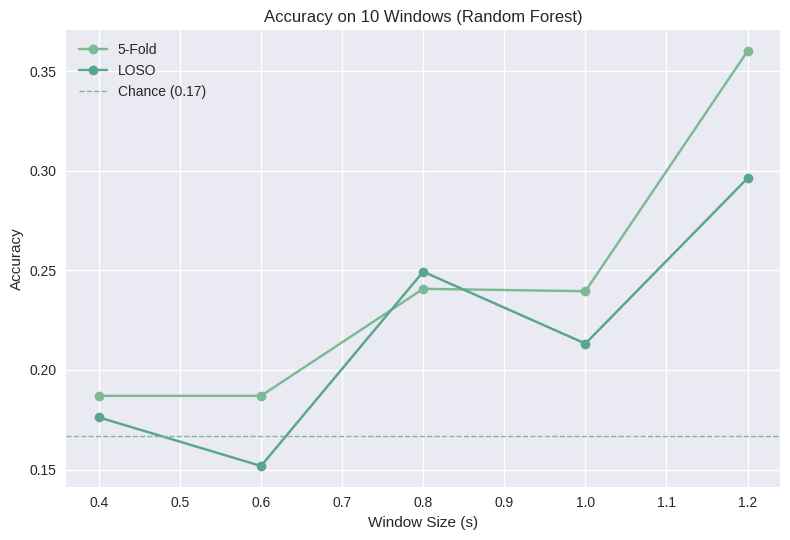

In [58]:
###Plotting window size comparisons
plt.plot(windowSizeDF["Window Size (s)"], windowSizeDF["5-Fold Mean"], marker="o", label="5-Fold") #Plots 5-Fold performance for window sizes
plt.plot(windowSizeDF["Window Size (s)"], windowSizeDF["LOSO Mean"], marker="o", label="LOSO") #Plots LOSO performance for window sizes
plt.axhline(chance, linestyle="--", linewidth=1, label=f"Chance ({chance:.2f})") #Chance = random guessing accuracy (Baseline)

plt.xlabel("Window Size (s)")
plt.ylabel("Accuracy")
plt.title(f"Accuracy on 10 Windows ({bestTunedModel})")
plt.legend()
plt.tight_layout()
plt.show()

#Metrics

In [61]:
### Best Tuned Model Metrics

yPred5Fold = cross_val_predict(bestEstimator, X, y, cv=skf) #X, y comes from cell 29
yPredLOSO = cross_val_predict(bestEstimator, X, y, cv=logo, groups=groups) #Generates the CV predictions for the final tuned model

def buildMetricsTable(yTrue, yPred, splitName): #Function to generate per-class metrics for 5-Fold and LOSO
  precision, recall, f1, support = precision_recall_fscore_support(yTrue, yPred, labels=np.arange(len(le_model.classes_)), zero_division=0) #Compute metric scores

  metricsDF = pd.DataFrame({ #Put metrics into a DF
      "Split": splitName,
      "Class": le_model.classes_,
      "Precision": np.round(precision, 4),
      "Recall": np.round(recall, 4),
      "F1-Score": np.round(f1, 4),
      "Support": support
  })

  return metricsDF

metric5FoldDF = buildMetricsTable(y, yPred5Fold, "5-Fold") #Run metrics on 5-Fold and LOSO
metricLOSO_DF = buildMetricsTable(y, yPredLOSO, "LOSO")

metricsCombinedDF = pd.concat([metric5FoldDF, metricLOSO_DF], ignore_index=True) #Combine dataframes
display(metricsCombinedDF)

accuracySummaryDF = pd.DataFrame([  #Make a dataframe to summarize the accuracy between two CV strategies
    {"Split": "5-Fold", "Accuracy": round(accuracy_score(y, yPred5Fold), 4)},
    {"Split": "LOSO", "Accuracy": round(accuracy_score(y, yPredLOSO), 4)}
])

display(accuracySummaryDF)

metricsCombinedDF.to_csv(OUT_DIR / "bestModelMetricsByClass.csv", index=False)
accuracySummaryDF.to_csv(OUT_DIR / "bestModelAccuracySummary.csv", index=False)

,Split,Class,Precision,Recall,F1-Score,Support
0,5-Fold,accel,0.1798,0.1702,0.1749,94
1,5-Fold,jump_takeoff,0.2235,0.2021,0.2123,94
2,5-Fold,landing,0.1837,0.1111,0.1385,81
3,5-Fold,sprint_mid,0.1765,0.1084,0.1343,83
4,5-Fold,start_run,0.2174,0.2586,0.2362,116
5,5-Fold,stop,0.2135,0.3115,0.2533,122
6,LOSO,accel,0.2048,0.1809,0.1921,94
7,LOSO,jump_takeoff,0.1235,0.1064,0.1143,94
8,LOSO,landing,0.1452,0.1111,0.1259,81
9,LOSO,sprint_mid,0.1837,0.1084,0.1364,83


,Split,Accuracy
0,5-Fold,0.2051
1,LOSO,0.1814


#Confusion Matrix Explanantion
In these confusion matrices the numbers represent how labels were predicted. So, the lines on the diagonal going from top left to bottom right represent how many True labels were predicted as their own. For example, the true label accel was correctly predicted 16 times. However, there were 12 instances where accel was predicted as jump_takeoff(5-Fold).
## Matrix Differences
The main difference between the 5-Fold and LOSO confusion matrices is start_run and jump_takeoff where 5-Fold was able to predict correctly a lot more consistently than LOSO.

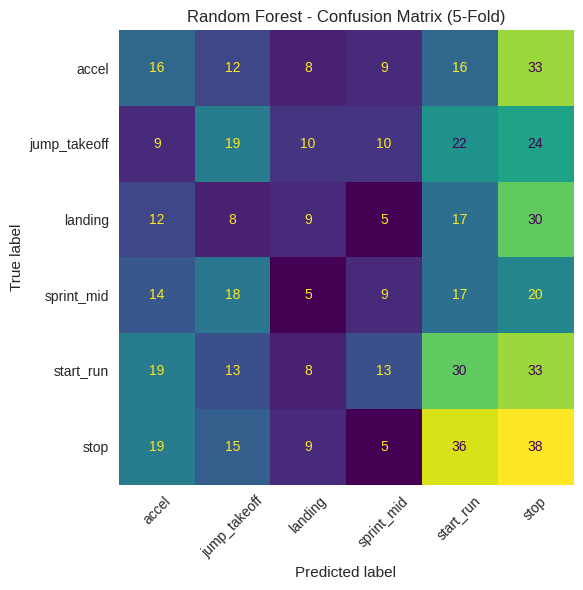

In [68]:
### Confusion Matrix 5-Fold

cm5Fold = confusion_matrix(y, yPred5Fold)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm5Fold, display_labels=le_model.classes_).plot(ax=ax, xticks_rotation=45, colorbar=False)

ax.set_title(f"{bestTunedModel} - Confusion Matrix (5-Fold)")
plt.grid(False)
plt.tight_layout()
plt.show()

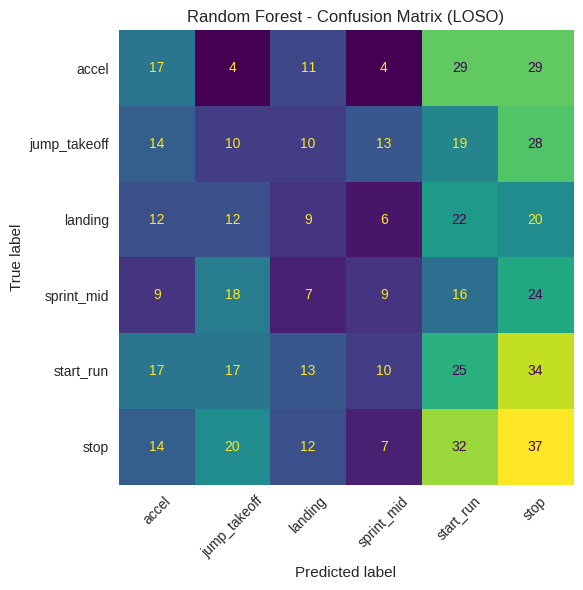

In [67]:
### Confusion Matrix LOSO

cmLOSO = confusion_matrix(y, yPredLOSO)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cmLOSO, display_labels=le_model.classes_).plot(ax=ax, xticks_rotation=45, colorbar=False)

ax.set_title(f"{bestTunedModel} - Confusion Matrix (LOSO)")
plt.grid(False)
plt.tight_layout()
plt.show()

#Error Analysis
Error analysis is performed on only LOSO due to it reflecting errors on unseen athletes. 5-Fold cross validation could possible underestimate errors since training and testing data could overlap. So, to identify weaknesses I believe LOSO is better to analyze.


In [69]:
### Error Analysis
##Stores most common LOSO misclassifications
errorPairs = []

for i, actualLabel in enumerate(le_model.classes_): #Loop through both actual and predicted labels in confusion matrix.
  for j, predictedLabel in enumerate(le_model.classes_):
    if i != j and cmLOSO[i, j] > 0: #We want to ignore the diagonal predicts since those are the correct predictions
      errorPairs.append({
          "Actual": actualLabel,
          "Predicted": predictedLabel,
          "Count": int(cmLOSO[i, j])
      })

errorAnalysisDF = pd.DataFrame(errorPairs).sort_values("Count", ascending=False).reset_index(drop=True) #Sort misclassifications from largest to smallest
display(errorAnalysisDF.head(10))

errorAnalysisDF.to_csv(OUT_DIR / "topMisclassificationsLOSO.csv", index=False)


,Actual,Predicted,Count
0,start_run,stop,34
1,stop,start_run,32
2,accel,stop,29
3,accel,start_run,29
4,jump_takeoff,stop,28
5,sprint_mid,stop,24
6,landing,start_run,22
7,landing,stop,20
8,stop,jump_takeoff,20
9,jump_takeoff,start_run,19


#System Intregration
The accuracy of predicting on df_clean is 100%. This means that the model learned patterns correctly on the training dataframe. Best Estimator was trained using df_clean and we are predicting on the same dataset So, 100% prediction accuracy is the expected output. If we have another dataset we can simply use this function to predict on the new dataset.

In [78]:
###System integration function used for how the model would be used in pratice
##Input is raw biosensor data, where it then creates the windows and features in which it outputs predictions.

def predictMotionFromRawDF(
    rawDF,
    trainedModel=bestEstimator,
    labelEncoder=le_model,
    samplingRate=sampling_rate_hz,
    windowSeconds=WINDOW_SECONDS,
    stepRatio=STEP_RATIO,
    minSamples=MIN_FEATURE_SAMPLES,
    minPurity=MIN_LABEL_PURITY
    ):

  inferenceDF = rawDF.copy()

  #Convert timestamps to datetime and create magnitudes if they are missing
  if "Timestamp" in inferenceDF.columns:
    inferenceDF["Timestamp"] = pd.to_datetime(inferenceDF["Timestamp"], errors="coerce")

  if "Acc_Mag" not in inferenceDF.columns and {"Acc_X", "Acc_Y", "Acc_Z"}.issubset(inferenceDF.columns):
    inferenceDF["Acc_Mag"] = np.sqrt(inferenceDF["Acc_X"]**2 + inferenceDF["Acc_Y"]**2 + inferenceDF["Acc_Z"]**2)

  if "Gyro_Mag" not in inferenceDF.columns and {"Gyro_X", "Gyro_Y", "Gyro_Z"}.issubset(inferenceDF.columns):
    inferenceDF["Gyro_Mag"] = np.sqrt(inferenceDF["Gyro_X"]**2 + inferenceDF["Gyro_Y"]**2 + inferenceDF["Gyro_Z"]**2)

  #This converts the raw data into windowed features
  featureInferenceDF = extract_window_features(
      inferenceDF,
      sampling_rate_hz=samplingRate,
      window_seconds=windowSeconds,
      step_ratio=stepRatio,
      min_samples=minSamples
  ).copy()

  if featureInferenceDF.empty: #Check if there were no valid windows, return empty DF if so
    return pd.DataFrame(columns=["Athlete_ID", "window_start", "window_end", "Predicted_Label"])

  #Filter out windows with weaker purity labels (< 0.5 purity)
  featureInferenceDF = featureInferenceDF[featureInferenceDF["label_purity"] >= minPurity].reset_index(drop=True)

  inferX = featureInferenceDF.drop(columns=META_COLS, errors="ignore").copy() #Make feature column and predict on enconded labels.
  yPredCodes = trainedModel.predict(inferX)
  yPredLabels = labelEncoder.inverse_transform(yPredCodes)

  outputDF = featureInferenceDF[["Athlete_ID", "window_start", "window_end", "Event_Label"]].copy() #Build our output dataframe containing the predictions
  outputDF = outputDF.rename(columns={"Event_Label": "Actual_Label"}) #***Added actual labels for confirmation but should be removed if using another raw dataset since won't always have correct labels to assume***
  outputDF["Predicted_Label"] = yPredLabels
  outputDF["Correct Label?"] = outputDF["Actual_Label"] == outputDF["Predicted_Label"]

  accuracyPercentage = outputDF["Correct Label?"].mean() * 100 #Confirm that the model trained and predicted with same dataset has no errors
  print(f"Accuracy: {accuracyPercentage:.2f}%")

  return outputDF

integrationPreviewDF = predictMotionFromRawDF(df_clean)
display(integrationPreviewDF.head())

integrationPreviewDF.to_csv(OUT_DIR / "systemIntegrationPreview.csv", index=False)

Accuracy: 100.00%


,Athlete_ID,window_start,window_end,Actual_Label,Predicted_Label,Correct Label?
0,A001,2025-05-11 12:14:54.667747,2025-05-11 12:14:55.167747,accel,accel,True
1,A001,2025-05-11 12:14:54.917747,2025-05-11 12:14:55.417747,accel,accel,True
2,A001,2025-05-11 12:14:56.167747,2025-05-11 12:14:56.667747,start_run,start_run,True
3,A001,2025-05-11 12:14:56.417747,2025-05-11 12:14:56.917747,stop,stop,True
4,A001,2025-05-11 12:14:56.917747,2025-05-11 12:14:57.417747,landing,landing,True
